In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

In [3]:
start = '2016-01-01'
end = '2026-04-01'
stock = 'GOOG'

data = yf.download(stock, start, end)

[*********************100%***********************]  1 of 1 completed


In [4]:
data.reset_index(inplace=True)

In [5]:
data

Price,Date,Close,High,Low,Open,Volume
Ticker,,GOOG,GOOG,GOOG,GOOG,GOOG
0,2016-01-04,36.789959,36.900055,36.265169,36.847489,65456000
1,2016-01-05,36.826660,37.293822,36.631262,37.018581,39014000
2,2016-01-06,36.878231,37.054783,36.149216,36.202777,38940000
3,2016-01-07,36.023743,36.624311,35.660226,36.218146,59274000
4,2016-01-08,35.432598,36.362960,35.359699,36.274684,49018000
...,...,...,...,...,...,...
2570,2026-03-25,289.589996,294.660004,287.369995,292.149994,22343000
2571,2026-03-26,280.739990,286.515015,279.049988,286.190002,29281200
2572,2026-03-27,273.760010,279.089996,273.480011,277.399994,25703300


In [6]:
ma_100_days = data.Close.rolling(100).mean()

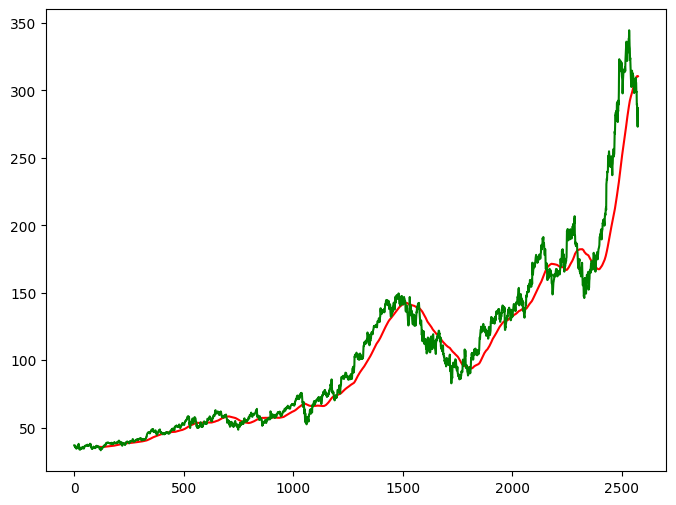

In [7]:
plt.figure(figsize=(8,6))
plt.plot(ma_100_days, 'r')
plt.plot(data.Close, 'g')
plt.show()

In [8]:
ma_200_days = data.Close.rolling(200).mean()

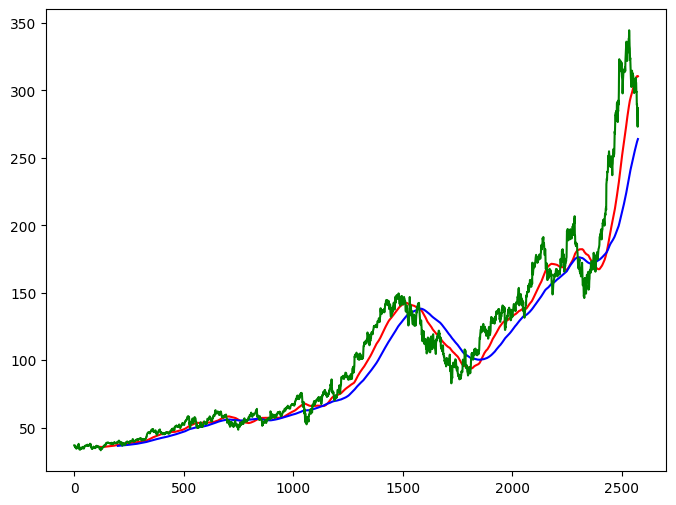

In [9]:
plt.figure(figsize=(8,6))
plt.plot(ma_100_days, 'r')
plt.plot(ma_200_days,'b')
plt.plot(data.Close,'g')
plt.show()

In [10]:
data.dropna(inplace=True)

In [11]:
data_train = pd.DataFrame(data.Close[0: int(len(data)*0.80)])
data_test = pd.DataFrame(data.Close[int(len(data)*0.80): len(data)])

In [12]:
data_train.shape[0]

2060

In [13]:
data_test.shape[0]

515

In [14]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))

In [15]:
data_train_scale = scaler.fit_transform(data_train)

In [16]:
x = []
y = []

for i in range(100, data_train_scale.shape[0]):
    x.append(data_train_scale[i-100:i])
    y.append(data_train_scale[i,0])
    

In [17]:
x, y = np.array(x), np.array(y)

In [18]:
from keras.layers import Dense, Dropout, LSTM
from keras.models import Sequential

In [19]:
model = Sequential()
model.add(LSTM(units = 50, activation = 'relu', return_sequences = True,
               input_shape = ((x.shape[1],1))))
model.add(Dropout(0.2))

model.add(LSTM(units = 60, activation='relu', return_sequences = True))
model.add(Dropout(0.3))

model.add(LSTM(units = 80, activation = 'relu', return_sequences = True))
model.add(Dropout(0.4))

model.add(LSTM(units = 120, activation = 'relu'))
model.add(Dropout(0.5))

model.add(Dense(units =1))

C:\Users\Nehay\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [20]:
model.compile(optimizer = 'adam', loss = 'mean_squared_error')

In [21]:
model.fit(x,y, epochs = 50, batch_size =32, verbose =1)

Epoch 1/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 14s 140ms/step - loss: 0.0431
Epoch 2/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 10s 168ms/step - loss: 0.0091
Epoch 3/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 9s 149ms/step - loss: 0.0081
Epoch 4/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 10s 168ms/step - loss: 0.0078
Epoch 5/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 11s 170ms/step - loss: 0.0070
Epoch 6/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 9s 151ms/step - loss: 0.0073
Epoch 7/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 15s 243ms/step - loss: 0.0068
Epoch 8/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 11s 183ms/step - loss: 0.0057
Epoch 9/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 11s 172ms/step - loss: 0.0059
Epoch 10/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 12s 192ms/step - loss: 0.0057
Epoch 11/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 11s 176ms/step - loss: 0.0059
Epoch 12/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 21s 182ms/step - loss: 0.0063
Epoch 13/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 11s 174ms/step - loss: 0.0050
Epoch 14/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 11s 170ms/step - loss: 0.0056
Epoch 15/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 10s 16

In [22]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100, 50)        │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 50)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100, 60)        │        26,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100, 60)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 100, 80)        │        45,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 100, 80)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 120)            │        96,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           121 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 536,285 (2.05 MB)

 Trainable params: 178,761 (698.29 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 357,524 (1.36 MB)

In [23]:
pas_100_days = data_train.tail(100)

In [24]:
data_test = pd.concat([pas_100_days, data_test], ignore_index=True)

In [25]:
data_test_scale  =  scaler.fit_transform(data_test)

In [26]:
x = []
y = []

for i in range(100, data_test_scale.shape[0]):
    x.append(data_test_scale[i-100:i])
    y.append(data_test_scale[i,0])
x, y = np.array(x), np.array(y)

In [27]:
y_predict = model.predict(x)

17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step


In [28]:
scale =1/scaler.scale_

In [29]:
y_predict = y_predict*scale

In [30]:
y = y*scale

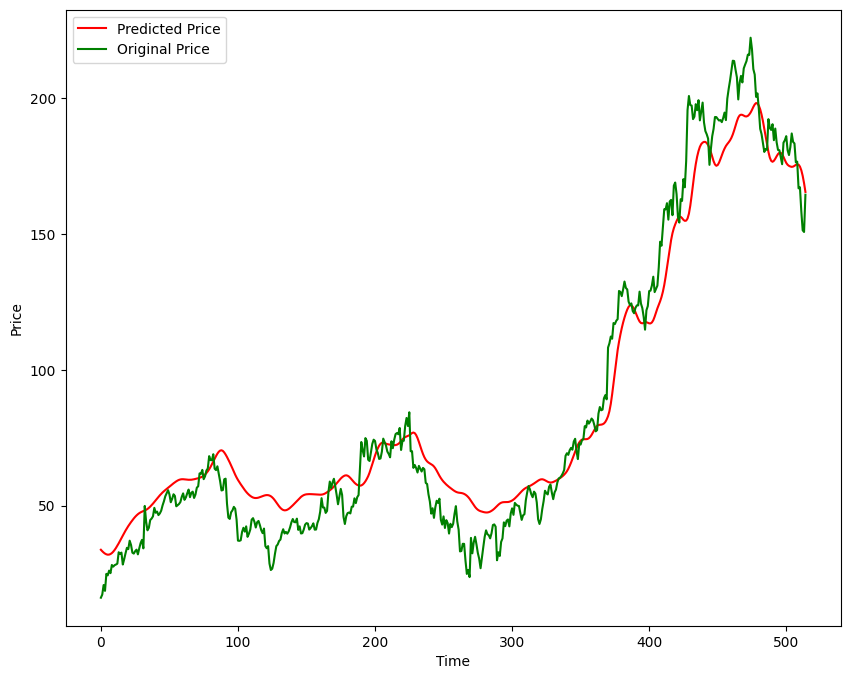

In [31]:
plt.figure(figsize=(10,8))
plt.plot(y_predict, 'r', label = 'Predicted Price')
plt.plot(y, 'g', label = 'Original Price')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()

In [32]:
model.save('Stock Predictions Model.keras')

In [33]:
model.save("Stock_Predictions_Model.h5")